In [1]:
# import necessary libraries

import pandas as pd
import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

import pickle

In [2]:
# download nltk resources

nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
# load dataset and select required columns

df = pd.read_csv('Tweets.csv')
df = df[['text', 'airline_sentiment']]
print(df.head())

                                                text airline_sentiment
0                @VirginAmerica What @dhepburn said.           neutral
1  @VirginAmerica plus you've added commercials t...          positive
2  @VirginAmerica I didn't today... Must mean I n...           neutral
3  @VirginAmerica it's really aggressive to blast...          negative
4  @VirginAmerica and it's a really big bad thing...          negative


In [4]:
# display dataset information

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   text               14640 non-null  object
 1   airline_sentiment  14640 non-null  object
dtypes: object(2)
memory usage: 228.9+ KB
None


In [5]:
# initialize stopwords and stemmer

stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

In [6]:
# define text preprocessing function

def preprocess_text(text):
    text = text.lower()
    words = word_tokenize(text)
    words = [
        stemmer.stem(word)
        for word in words
        if word not in stop_words
        and word not in string.punctuation
    ]
    return " ".join(words)

In [7]:
# apply preprocessing on text column

df['clean_text'] = df['text'].apply(preprocess_text)

In [8]:
# separate input and output data

X = df['clean_text']
y = df['airline_sentiment']

In [9]:
# convert text data into numerical form using TF-IDF

vectorizer = TfidfVectorizer(max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

In [10]:
# split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
# train Logistic Regression model

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [12]:
# save trained Logistic Regression model

with open('sentiment_model.pkl', 'wb') as file:
    pickle.dump(model, file)

# save TF-IDF vectorizer

with open('sentiment_vectorizer.pkl', 'wb') as file:
    pickle.dump(vectorizer, file)

print("Model and Vectorizer saved successfully")

Model and Vectorizer saved successfully


In [13]:
# predict sentiment for test data

y_pred = model.predict(X_test)
print(y_pred)

['positive' 'negative' 'negative' ... 'negative' 'negative' 'neutral']


In [14]:
# display accuracy and classification report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

classification_rep = classification_report(y_test, y_pred)
print("\nClassification Report:\n", classification_rep)

Accuracy Score: 0.7991803278688525

Classification Report:
               precision    recall  f1-score   support

    negative       0.83      0.94      0.88      1889
     neutral       0.67      0.50      0.57       580
    positive       0.79      0.61      0.69       459

    accuracy                           0.80      2928
   macro avg       0.76      0.68      0.71      2928
weighted avg       0.79      0.80      0.79      2928



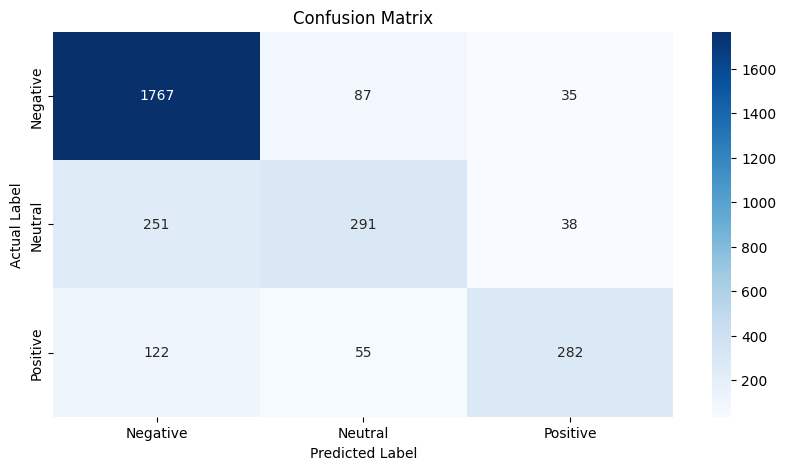

In [15]:
# create and visualize confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()